# lucidml — Decision Tree demo

Using the `lucidml` package on a classic non-linear problem: two concentric
rings that a linear model cannot separate but a decision tree can.

```bash
pip install -e ".[dev]"   # from the repo root, then run this notebook
```


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from lucidml import DecisionTreeClassifier, entropy, gini, classification_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. The impurity measures

`lucidml` exposes the impurity functions directly. A 50/50 binary node has
entropy 1 and Gini 0.5; a pure node has impurity 0.

In [2]:
half = np.array([0, 0, 1, 1])
pure = np.array([1, 1, 1])
print(f"entropy(50/50) = {entropy(half):.3f}   gini(50/50) = {gini(half):.3f}")
print(f"entropy(pure)  = {entropy(pure):.3f}   error(pure) = {classification_error(pure):.3f}")

entropy(50/50) = 1.000   gini(50/50) = 0.500
entropy(pure)  = 0.000   error(pure) = 0.000


## 2. Non-linear (ring-shaped) data

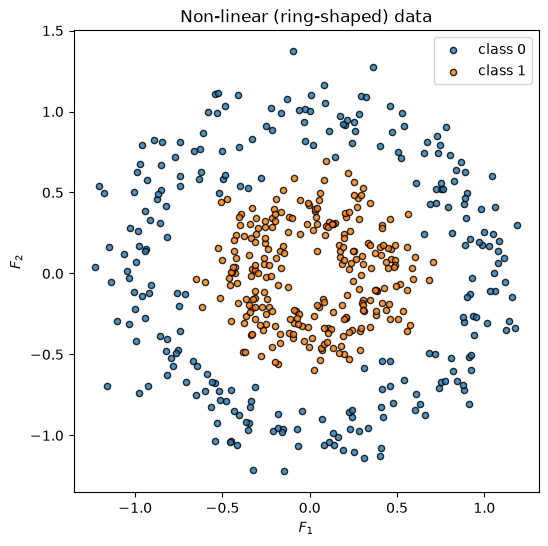

In [3]:
X, y = make_circles(n_samples=500, factor=0.4, noise=0.12, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=20, edgecolor='k', alpha=.8, label='class 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=20, edgecolor='k', alpha=.8, label='class 1')
ax.set_title('Non-linear (ring-shaped) data')
ax.set_xlabel('$F_1$'); ax.set_ylabel('$F_2$'); ax.legend()
plt.show()

## 3. Fit the lucidml tree

In [4]:
tree = DecisionTreeClassifier(max_depth=8, min_samples_split=5, impurity="entropy")
tree.fit(X_train, y_train)

print(f"lucidml DecisionTree | train accuracy = {tree.score(X_train, y_train):.3f}")
print(f"lucidml DecisionTree | test  accuracy = {tree.score(X_test, y_test):.3f}")
print(f"fitted tree depth    = {tree.get_depth()}")

lucidml DecisionTree | train accuracy = 0.991
lucidml DecisionTree | test  accuracy = 0.947
fitted tree depth    = 6


## 4. Decision boundary

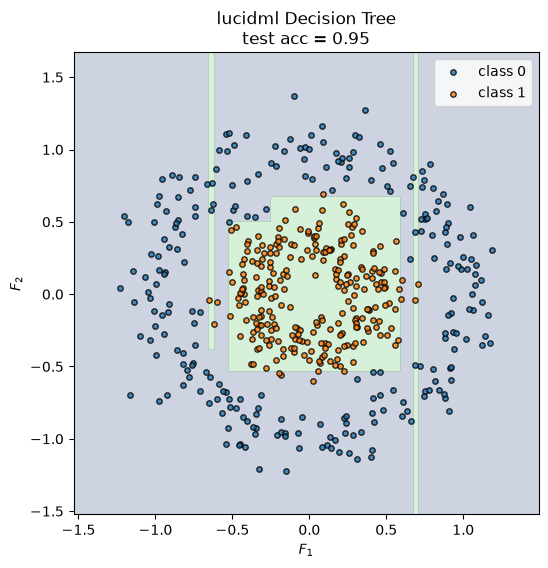

In [5]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - .3, X[:, 0].max() + .3
    y_min, y_max = X[:, 1].min() - .3, X[:, 1].max() + .3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=.25, levels=[-.5, .5, 1.5])
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=15, edgecolor='k', alpha=.8, label='class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=15, edgecolor='k', alpha=.8, label='class 1')
    ax.set_title(title); ax.set_xlabel('$F_1$'); ax.set_ylabel('$F_2$')


fig, ax = plt.subplots(figsize=(6, 6))
plot_decision_boundary(tree, X, y, ax, f'lucidml Decision Tree\ntest acc = {tree.score(X_test, y_test):.2f}')
ax.legend(); plt.show()

## 5. Logistic Regression vs. Decision Tree

A linear model fits a single hyperplane, so on ring-shaped data it lands near
chance. The tree carves the space into axis-aligned regions and separates the
rings.

Logistic Regression | test accuracy = 0.467
lucidml DecisionTree | test accuracy = 0.947


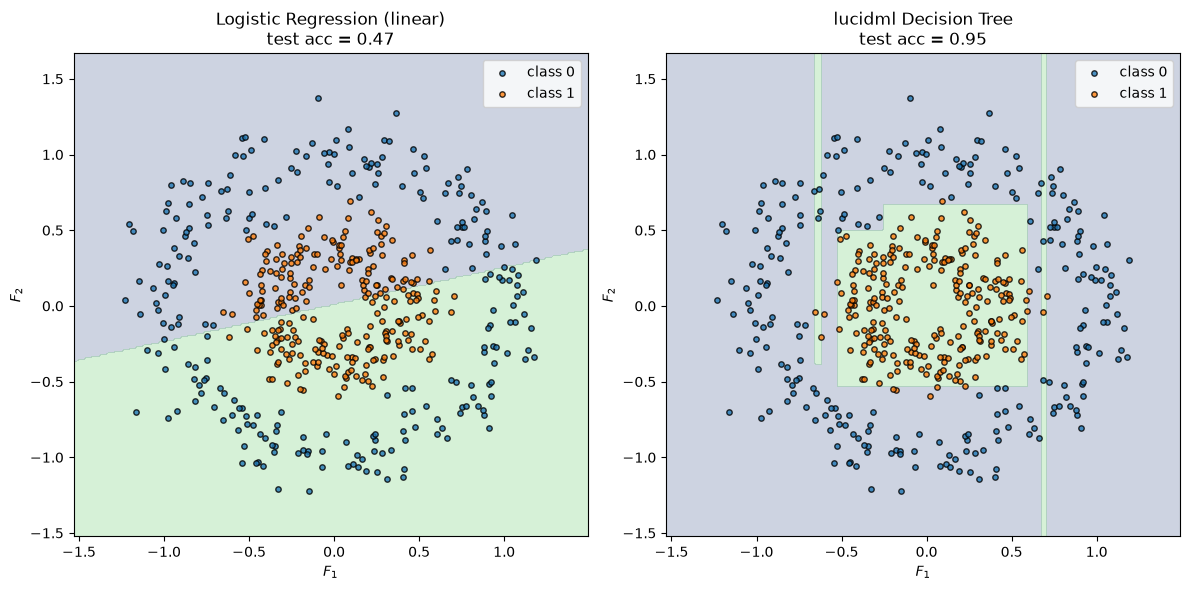

In [6]:
logreg = LogisticRegression().fit(X_train, y_train)
lr_acc = logreg.score(X_test, y_test)
dt_acc = tree.score(X_test, y_test)
print(f"Logistic Regression | test accuracy = {lr_acc:.3f}")
print(f"lucidml DecisionTree | test accuracy = {dt_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_decision_boundary(logreg, X, y, axes[0], f'Logistic Regression (linear)\ntest acc = {lr_acc:.2f}')
plot_decision_boundary(tree, X, y, axes[1], f'lucidml Decision Tree\ntest acc = {dt_acc:.2f}')
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Effect of tree depth

Shallow trees underfit; very deep trees start fitting the noise. This motivates
the ensemble methods on the `lucidml` roadmap (Random Forests, gradient
boosting).

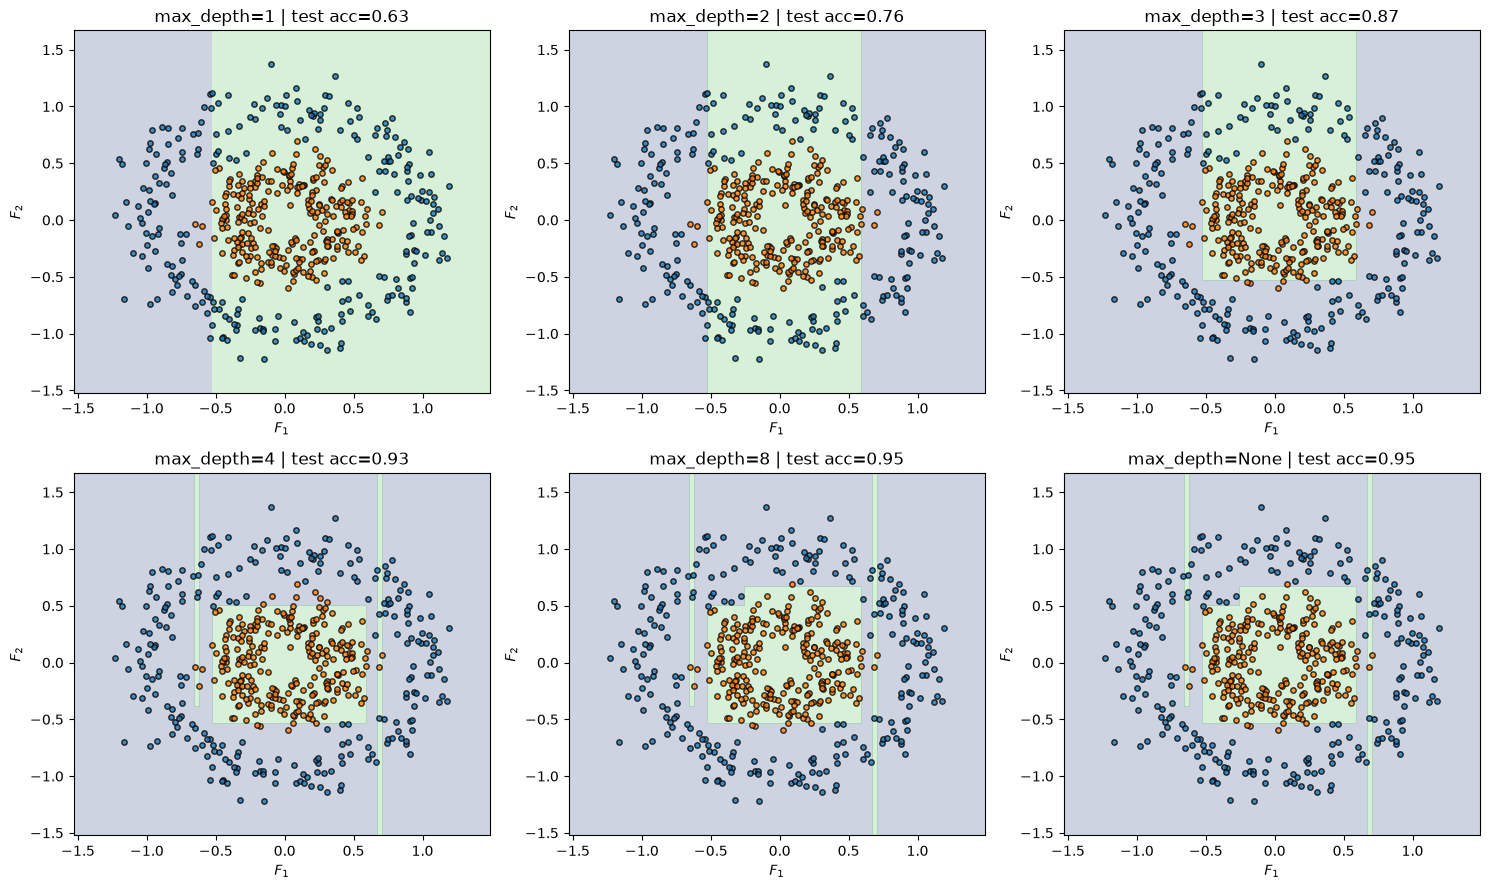

In [21]:
depths = [1, 2, 3, 4, 8, None]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, d in zip(axes.ravel(), depths):
    t = DecisionTreeClassifier(max_depth=d, min_samples_split=5).fit(X_train, y_train)
    plot_decision_boundary(t, X, y, ax, f'max_depth={d} | test acc={t.score(X_test, y_test):.2f}')
plt.tight_layout(); plt.show()